In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1. Feature Engineering: People shop based on the calendar, not the algorithm.
df_q3 = pd.read_csv('../data/q3_retail_promotions.csv')
df_q3['transaction_date'] = pd.to_datetime(df_q3['transaction_date'])

df_q3['year'] = df_q3['transaction_date'].dt.year
df_q3['month'] = df_q3['transaction_date'].dt.month
df_q3['day_of_week'] = df_q3['transaction_date'].dt.dayofweek
df_q3['is_month_end'] = (df_q3['transaction_date'].dt.day >= 25).astype(int)

# Crucial: Sort by time to preserve reality.
df_q3 = df_q3.sort_values('transaction_date').reset_index(drop=True)
display(df_q3[['transaction_date', 'year', 'month', 'day_of_week', 'is_month_end']].sample(5))

,transaction_date,year,month,day_of_week,is_month_end
780,2024-01-21,2024,1,6,0
192,2022-06-04,2022,6,5,0
393,2023-01-15,2023,1,6,0
660,2023-10-20,2023,10,4,0
684,2023-11-08,2023,11,2,0


In [2]:
# 2. Temporal Split (80/20)
split_idx = int(len(df_q3) * 0.8)

train_df = df_q3.iloc[:split_idx]
test_df = df_q3.iloc[split_idx:]

X_train = train_df.drop(['items_sold', 'transaction_date', 'store_id'], axis=1)
y_train = train_df['items_sold']

X_test = test_df.drop(['items_sold', 'transaction_date', 'store_id'], axis=1)
y_test = test_df['items_sold']

**Why Temporal Splits Matter:**
Using a standard random split would be a major error. If we shuffle the rows, the model uses data from the future (e.g., 2024) to predict the past (e.g., 2023), causing data leakage. By using a chronological split, we force the model to learn from historical patterns and predict unseen future months, mirroring how a real retail business operates.


In [3]:
# 3. The Pipeline
categorical_features = ['promotion_type', 'location_type', 'store_size']
numerical_features = ['is_weekend', 'is_festival', 'competition_density', 'year', 'month', 'day_of_week', 'is_month_end']

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ('num', StandardScaler(), numerical_features)
])

### Preprocessing Pipeline Explanation

A ColumnTransformer is used to apply different preprocessing steps to different types of features:

- Categorical features are encoded using OneHotEncoder to convert them into numerical format.
- Numerical features are scaled using StandardScaler to ensure equal contribution to the model.

The pipeline ensures that preprocessing is applied consistently to both training and test data, preventing data leakage and making the workflow reproducible.

In [4]:
# 4. Model Training & Evaluation
lr_pipe = Pipeline([('pre', preprocessor), ('reg', LinearRegression())])
rf_pipe = Pipeline([('pre', preprocessor), ('reg', RandomForestRegressor(random_state=42))])

lr_pipe.fit(X_train, y_train)
rf_pipe.fit(X_train, y_train)

lr_preds = lr_pipe.predict(X_test)
rf_preds = rf_pipe.predict(X_test)

print("Linear Regression:")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, lr_preds)):.2f}")
print(f"MAE:  {mean_absolute_error(y_test, lr_preds):.2f}\n")

print("Random Forest Regressor:")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, rf_preds)):.2f}")
print(f"MAE:  {mean_absolute_error(y_test, rf_preds):.2f}")

Linear Regression:
RMSE: 27.13
MAE:  21.07

Random Forest Regressor:
RMSE: 31.15
MAE:  24.91


### Model Performance Interpretation
**Linear Regression** outperformed **Random Forest** with lower RMSE and MAE scores. This suggests that the relationship between the features (such as festivals and location) and `items_sold` is predominantly linear and does not require a highly complex non-linear model. The Random Forest model, while flexible, may have overfit the training noise or required significantly more hyperparameter tuning to generalize as well as the linear baseline.

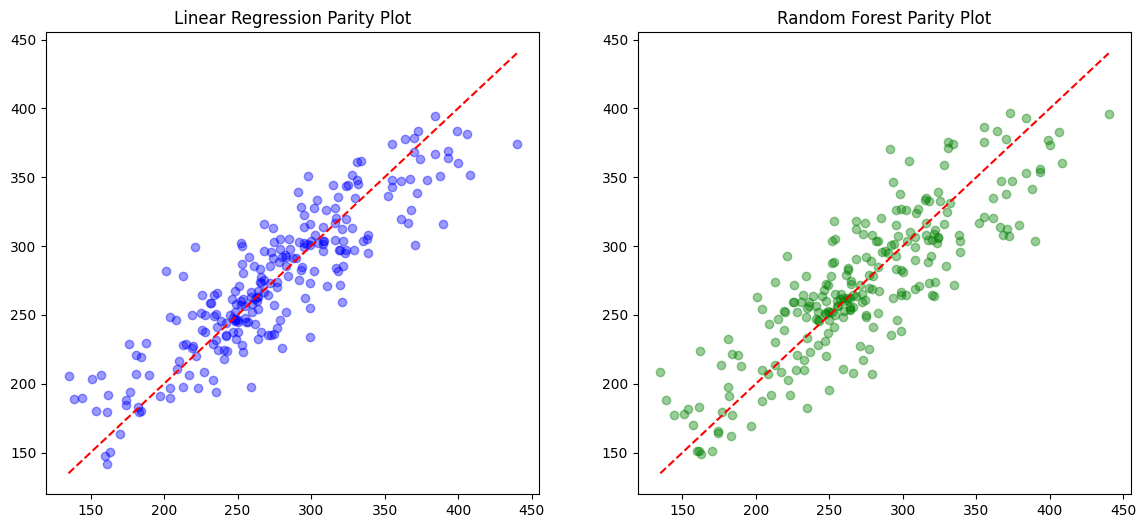


The Ugly Truth - Top 5 Driving Features:


,Feature,Importance
12,is_festival,0.173552
10,store_size_small,0.166445
7,location_type_urban,0.109712
16,day_of_week,0.088706
11,is_weekend,0.066189


In [5]:
# Parity Plots
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.scatter(y_test, lr_preds, alpha=0.4, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Linear Regression Parity Plot')

plt.subplot(1, 2, 2)
plt.scatter(y_test, rf_preds, alpha=0.4, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Random Forest Parity Plot')
plt.show()

# Extracting what actually drove the decisions
feat_names = list(rf_pipe.named_steps['pre'].named_transformers_['cat'].get_feature_names_out()) + numerical_features
importances = rf_pipe.named_steps['reg'].feature_importances_

importance_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)
print("\nThe Ugly Truth - Top 5 Driving Features:")
display(importance_df.head(5))

### Parity Plot Interpretation
The parity plots compare predicted versus actual values to visualize model accuracy:
* Points closer to the **45-degree diagonal line** indicate higher prediction accuracy.
* **Linear Regression** shows tighter clustering around the diagonal, confirming its superior performance.
* **Random Forest** shows more spread (variance), indicating higher prediction errors on the test set.

### **Feature Importance Interpretation**

Based on the Random Forest feature importance scores, the **top 5 most influential features** are:
1. **is_festival:** The strongest driver, indicating high sensitivity to seasonal spikes.
2. **store_size_small:** Suggests store capacity is a major constraint on volume.
3. **location_type_urban:** Reflects higher footfall in city centers.
4. **is_weekend / day_of_week:** Confirms that customer behavior is cyclically driven.

### **Strategic Business Insight**
The analysis reveals that **timing (festivals/weekends)** and **store context (size/location)** are more significant drivers of sales than the promotion type alone. Strategically, the chain should focus on operational readiness during these peak periods rather than relying solely on aggressive discounting.